In [1]:
import gc
import argparse
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import muspan as ms



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in

In [60]:
# Load the domain inside the worker process
# domain = ms.io.load_domain("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/muspan/domains/IPF_RBH_16_muspan_domain.muspan")

domain = ms.io.load_domain("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/muspan/domains/COPD_R038_V2_muspan_domain.muspan")

MuSpAn domain loaded successfully. Domain summary:
Domain name: COPD_R038_V2
Number of objects: 405939
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts', 'Cell centroids']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Nucleus Area', 'Transcript ID', 'Cell Type'] 
Networks: ['Delaunay CC', 'Delaunay CC filtered', 'Proximity_30um'] 
Distance matrices: []


In [61]:
qTrans = ms.query.query(domain, ('Collection',), 'is', 'Transcripts')
boundCells = ms.query.query(domain, ("Collection",), "is", "Cell boundaries")
query_16S = ms.query.query(domain, ('label', 'Transcript ID'), 'is', '16S')

In [ ]:
# Visualise transcripts, colored by 'Transcript'
fig, ax = plt.subplots(figsize=(20, 12))
ms.visualise.visualise(
        domain,
        color_by=("label", "Cell Type"),
        objects_to_plot=boundCells,
        shape_kwargs=dict(alpha=1, linewidth=0.005, edgecolor="#00000000"), ax=ax
    )
ms.visualise.visualise(domain,
                       color_by=("label", "Transcript ID"), 
                       objects_to_plot=query_16S, 
                       marker_size=1, 
                       ax=ax, 
                       shape_kwargs=dict(color = "#ee7976")
                       )

# plt.savefig("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/16S/muspan/16S_IPF16.pdf", dpi=600)
plt.savefig("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/16S/muspan/16S_IPF16.png", dpi=600)

In [52]:
print(type(query_16S))
print(query_16S)

# Most importantly:
qTrans_check = ms.query.query(domain, ('Collection',), 'is', 'Transcripts')
print(qTrans_check)
print(domain)  # or ms.io.print_summary(domain)

print(len(ax.patches))   # before second visualise call
# then after:
print(len(ax.patches))   # how many were added by query_16S visualise call

<class 'muspan.query.query.query'>
value is 16S
Collection value is 2
Domain name: IPF_RBH_16
Number of objects: 202636
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts', 'Cell centroids']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Nucleus Area', 'Transcript ID', 'Cell Type'] 
Networks: ['Delaunay CC', 'Delaunay CC filtered', 'Proximity_30um'] 
Distance matrices: []
0
0


patches after boundCells: 42579
collections after boundCells: 0
patches after query_16S: 42579
collections after query_16S: 1


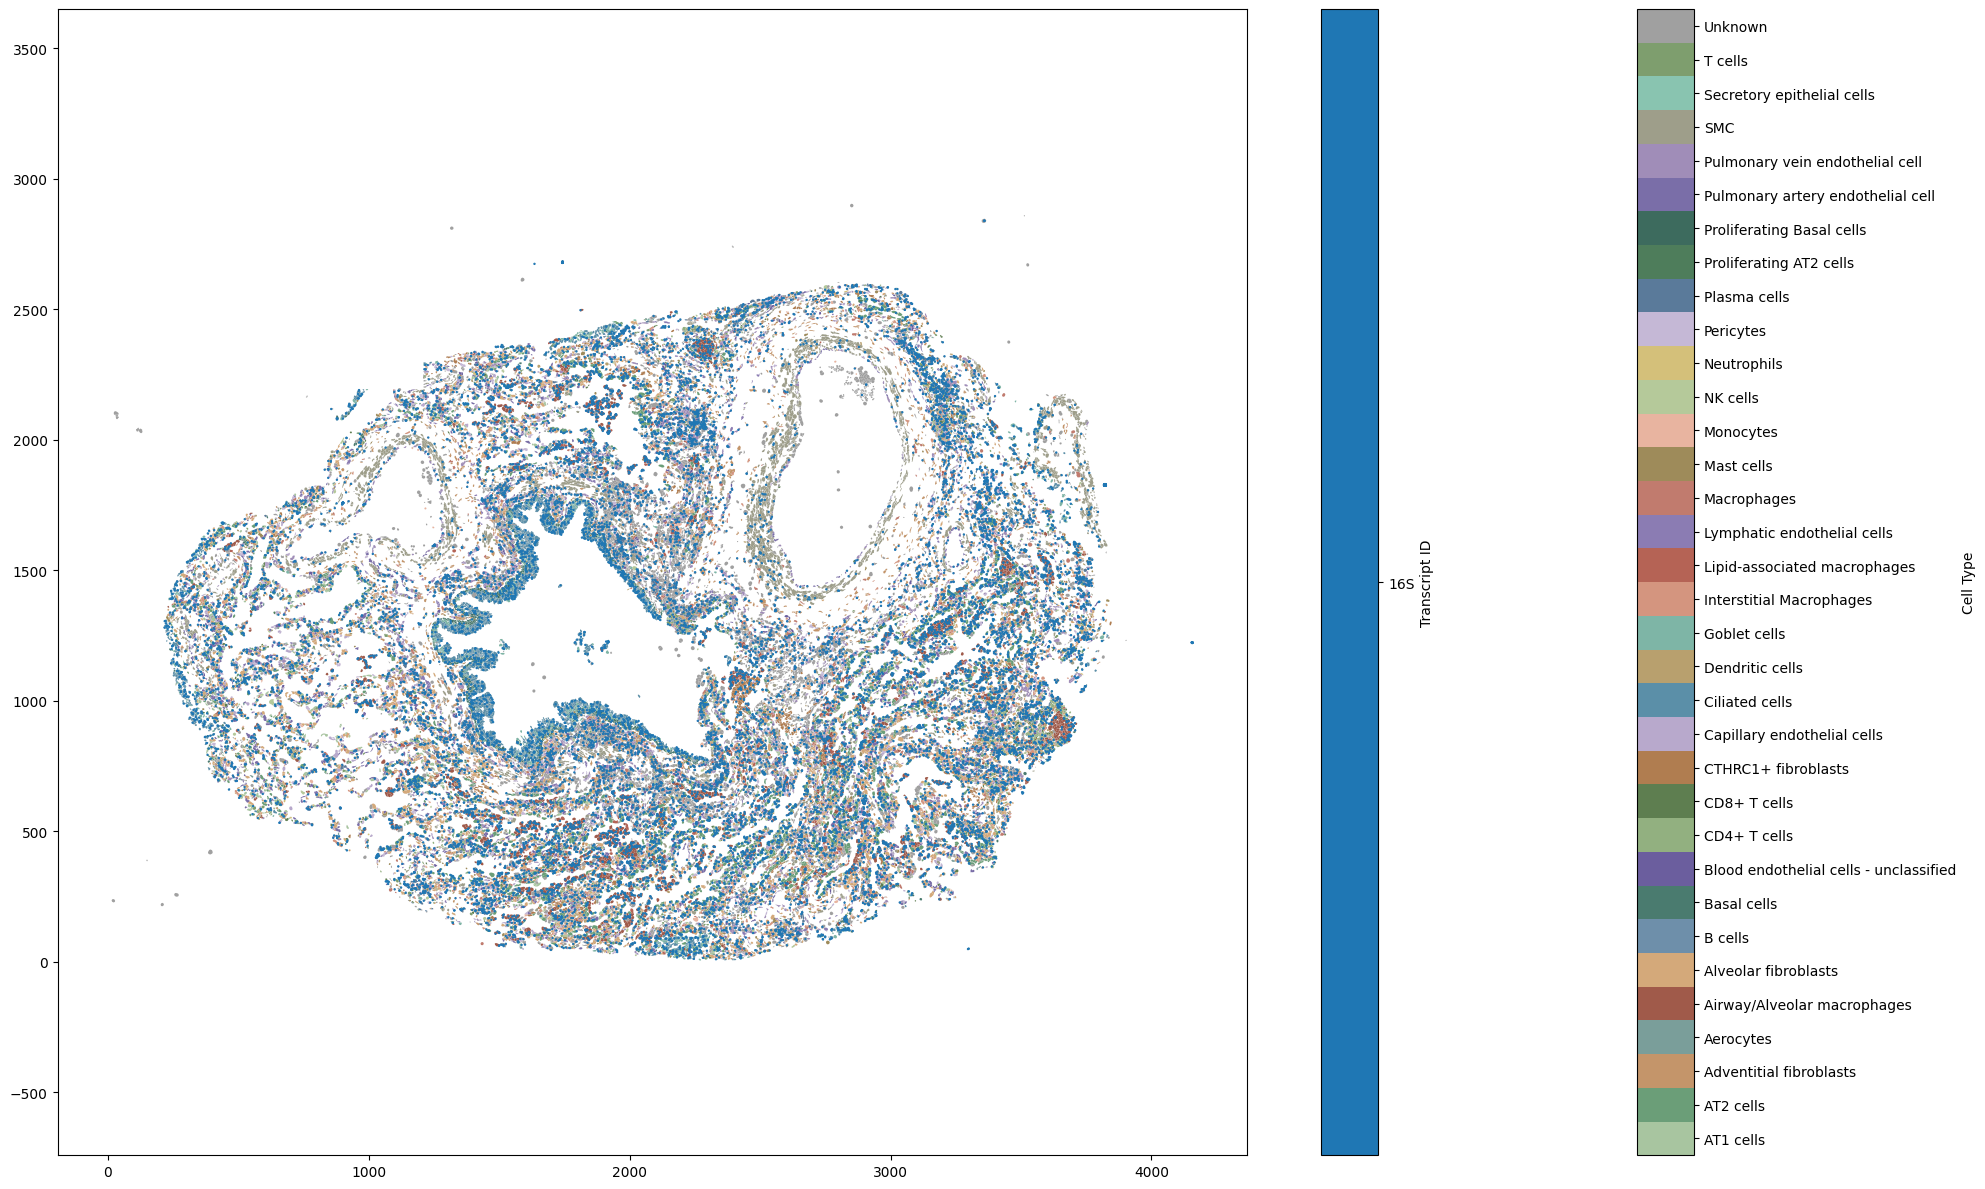

In [53]:
fig, ax = plt.subplots(figsize=(20, 12))

ms.visualise.visualise(
    domain,
    color_by=("label", "Cell Type"),
    objects_to_plot=boundCells,
    shape_kwargs=dict(alpha=1, linewidth=0.005, edgecolor="#00000000"),
    ax=ax
)

print("patches after boundCells:", len(ax.patches))      # <-- add this
print("collections after boundCells:", len(ax.collections))

ms.visualise.visualise(
    domain,
    color_by=("label", "Transcript ID"),
    objects_to_plot=query_16S,
    marker_size=0.5,
    ax=ax,
    shape_kwargs=dict(color="#ee7976")
)

print("patches after query_16S:", len(ax.patches))       # <-- add this
print("collections after query_16S:", len(ax.collections))

# Testing mapping cell ID

In [ ]:
base_dir = Path("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output")

In [ ]:
def map_cell_types_to_domain(
    cell_id_to_type_df,
    domain,
    cell_id,
    label_name="Cell Type",
    cluster_labels=None,
    logger=None,
):
    """Maps cell type (cluster) labels from an df to a domain object on cell ID.

    Args:
        cell_id_to_type_df (pd.DataFrame):
            A DataFrame containing cell IDs and their corresponding types.
        domain: An object representing a spatial or logical domain, with cell IDs
            accessible via `domain.labels["Cell ID"]["labels"]` and a method
            `add_labels` for adding new labels.
        cell_id (str): The column name in `cell_id_to_type_df` that contains the cell
            IDs.
        cluster_labels (str): The column name in `cell_id_to_type_df` that contains the
            cluster or cell type labels.
        label_name (str): The name of the label to be added to the domain for cell types.
            Default is "Cell Type".
        logger: A logging object for logging information and debugging.

    Returns:
        None. The function modifies the `domain` object in place by adding a
        new label with the mapped cell types.
    """
    # Get cell IDs from the domain in their original order (preserving duplicates)
    domain_cell_ids_ordered = [
        str(cell_id) for cell_id in domain.labels["Cell ID"]["labels"]
    ]

    # Get unique cell IDs for filtering cell_id_to_type_df
    domain_cell_ids_unique = set(domain_cell_ids_ordered)

    logger.info(f"Number of unique cells in the domain: {len(domain_cell_ids_unique)}")
    logger.info(
        f"Total cell entries in domain (including duplicates): "
        f"{len(domain_cell_ids_ordered)}"
    )

    # Filter cell_id_to_type_df to include only cells in the area of interest
    filt_cell_id_to_type_df = cell_id_to_type_df[
        cell_id_to_type_df[cell_id].isin(domain_cell_ids_unique)
    ]

    logger.info(
        f"Filtered cell_id_to_type_df from {len(cell_id_to_type_df)}"
        f" to {len(filt_cell_id_to_type_df)} cells"
    )

    # Add cell cluster IDs
    logger.info("Adding cell_type IDs to domain with cluster labels")

    # Create a mapping from cell_id to cell_type on filtered data
    cell_id_to_type = dict(
        zip(
            filt_cell_id_to_type_df[cell_id],
            filt_cell_id_to_type_df[cluster_labels],
        )
    )

    # Get cell types in the same order as domain cell IDs
    cell_types_ordered = [
        cell_id_to_type.get(cell_id, "Unknown") for cell_id in domain_cell_ids_ordered
    ]

    # Add cell_type label to the domain
    domain.add_labels(label_name=label_name, labels=cell_types_ordered)

    logger.info(f"Label keys in domain: {domain.labels.keys()}")
    logger.info(f"Length of cell_types_ordered: {len(cell_types_ordered)}")
    logger.info(f"Length of domain cell IDs: {len(domain_cell_ids_ordered)}")
    logger.info(
        f"Number of 'Unknown' cell types: {cell_types_ordered.count('Unknown')}"
    )

    # Return muspan domain with cell types mapped
    return domain


In [ ]:

# Load cell id and cell type dictionary
cell_id_to_type_df_level1 = pd.read_csv(
    base_dir / "output/muspan/cell_id_to_cluster_labels_level1.csv"
)
cell_id_to_type_df_level2 = pd.read_csv(
    base_dir / "output/muspan/cell_id_to_cluster_labels_level2.csv"
)
cell_id_to_type_df_level3 = pd.read_csv(
    base_dir / "output/muspan/cell_id_to_cluster_labels_level3.csv"
)
